# 1.0 Import modules and data

## 1.1 Import modules

### 1.1.1 Import general modules

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import arviz as az
import xarray as xr

# get NZTM coordinates
from pyproj import CRS, Transformer
crs_wgs84 = CRS.from_epsg(4326)
crs_nztm  = CRS.from_epsg(2193)  # NZ Transverse Mercator
to_proj   = Transformer.from_crs(crs_wgs84, crs_nztm, always_xy=True)

### 1.1.2 Import jax_models

In [8]:
import arviz as az
import numpyro as numpyro
import jax as jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, log_likelihood
from scipy.special import logsumexp
numpyro.set_platform("cpu")
numpyro.set_host_device_count(4)
numpyro.enable_validation(True)

### 1.1.3 Import okrig

In [9]:
from VarioCorreKrigE.okrig import pairwise_distances, merge_blocks
from VarioCorreKrigE.bayes_krig import bayes_krig

## 1.2 Import and standardize data

In [10]:
# kappa0
k0 = pd.read_csv(r'Data/kappa0.csv')
k0_coords_utm = [to_proj.transform(lon, lat) for lon, lat in k0[['sta_lon', 'sta_lat']].values]
k0[['X_m','Y_m']] = np.array(k0_coords_utm)
k0[['X_km','Y_km']] = np.array(k0_coords_utm)/1000

# target values
target_values = pd.read_csv(r'Data/NZVS30_XYZ_3000m.xyz', header=None)
target_values = target_values.rename(columns={0:'X_m', 1:'Y_m', 2:'vs30'})
target_values[['X_km','Y_km']] = target_values[['X_m','Y_m']]/1000

# z-standardize data
mu  = k0['k0_mean'].mean()
sig = k0['k0_mean'].std(ddof=0)
k0['k0_z'] = (k0['k0_mean'] - mu) / sig

# 2.0 Model definitions and prior distributions

## 2.1 Distance dissimilarity functions

In [11]:
def getEucDistanceFromXY(X):
    """
    Computes pairwise Euclidean distances between points in 2D Cartesian space.

    Input
    -----
    X : array (n × 2)
        Column 0: X coordinate
        Column 1: Y coordinate

    Output
    ------
    dist : array (n × n)
        Pairwise Euclidean distances
    """
    # Differences using broadcasting
    dx = jnp.reshape(X[:,0], [-1,1]) - jnp.reshape(X[:,0], [1,-1])
    dy = jnp.reshape(X[:,1], [-1,1]) - jnp.reshape(X[:,1], [1,-1])

    # Squared distance
    sq_dist = dx*dx + dy*dy

    # Numerical safety (not really needed but consistent with your style)
    sq_dist = jnp.clip(sq_dist, 0, jnp.inf)

    # Final distance matrix
    dist = jnp.sqrt(sq_dist)

    # Zero diagonal
    dist = dist.at[jnp.diag_indices_from(dist)].set(0.0)

    return dist

def getSoilDissimilarity(X):
    sq_dist = jnp.square(jnp.reshape(X[:,2], [-1,1]) - jnp.reshape(X[:,2], [1,-1]))
    sq_dist = jnp.clip(sq_dist, 0, jnp.inf)
    dist = jnp.sqrt(sq_dist)
    return dist

## 2.1 Euclidean distance model

$$
\rho_{\mathrm{E}}(d_{\mathrm{E}}; \boldsymbol{\psi}_{\mathrm{E}}) = \exp(- (d_{\mathrm{E}}/\ell_{\mathrm{E}})^{\gamma_{\mathrm{E}}})
$$

In [12]:
# Deterministic correlation functions
def rhoE(X, LEt, gammaE, nugget=1e-6):
    distE = getEucDistanceFromXY(X)
    K = jnp.exp(-1.0 * jnp.multiply(jnp.power(distE, gammaE), 1.0/LEt))

    K = K.at[jnp.diag_indices(X.shape[0])].add(nugget)
    return K

# Probabilistic correlation model
def modelE(X, idx, z):
    # Define Prior Distributions
    LE = numpyro.sample("LE", dist.InverseGamma(concentration=3, rate=100))
    gamma2 = numpyro.sample("gamma2", dist.Beta(2,2))

    # Compute transformed parameters
    gammaE = numpyro.deterministic("gammaE", 2.0*gamma2)
    LEt = numpyro.deterministic("LEt", jnp.power(LE, gammaE))

    # Specify observational model for each event
    z = [numpyro.sample("z_{}".format(id),
              dist.MultivariateNormal(0, rhoE(X[i], LEt, gammaE)),
              obs = z[i]) for i,id in enumerate(idx)]

## 2.2 Euclidean distance model w/ nugget

In [13]:
# Deterministic correlation functions
def rhoEn(X, LEt, gammaE, nugget):
    distE = getEucDistanceFromXY(X)
    K = jnp.exp(-1.0 * jnp.multiply(jnp.power(distE, gammaE), 1.0/LEt))

    K = K.at[jnp.diag_indices(X.shape[0])].add(nugget)
    return K

# Probabilistic correlation model
def modelEn(X, idx, z):
    # Define Prior Distributions
    LE = numpyro.sample("LE", dist.InverseGamma(concentration=3, rate=100))
    gamma2 = numpyro.sample("gamma2", dist.Beta(2,2))

    # Nugget standard deviation prior
    nugget_sd = numpyro.sample("nugget_sd", dist.HalfCauchy(2.5))
    nugget = numpyro.deterministic("nugget", jnp.square(nugget_sd))

    # Compute transformed parameters
    gammaE = numpyro.deterministic("gammaE", 2.0*gamma2)
    LEt = numpyro.deterministic("LEt", jnp.power(LE, gammaE))

    # Specify observational model for each event
    z = [numpyro.sample("z_{}".format(id),
              dist.MultivariateNormal(0, rhoEn(X[i], LEt, gammaE, nugget)),
              obs = z[i]) for i,id in enumerate(idx)]

## 2.3 Euclidean distance and soil dissimilarity w/ nugget

In [14]:
# Deterministic correlation functions
def rhoESn(X, LEt, gammaE, LS, nugget):
    distE = getEucDistanceFromXY(X)
    KE = jnp.exp(-1.0 * jnp.multiply(jnp.power(distE, gammaE), 1.0/LEt))

    distS = getSoilDissimilarity(X)
    KS = jnp.exp(-1.0 * jnp.multiply(distS, 1.0/LS))

    K = KE * KS
    K = K.at[jnp.diag_indices(X.shape[0])].add(nugget)
    return K

# Probabilistic correlation model
def modelESn(X, idx, z):
    # Define Prior Distributions
    LE = numpyro.sample("LE", dist.InverseGamma(concentration=3, rate=100))
    gamma2 = numpyro.sample("gamma2", dist.Beta(2,2))
    LS = numpyro.sample("LS", dist.InverseGamma(2, 100))

    # Nugget standard deviation prior
    nugget_sd = numpyro.sample("nugget_sd", dist.HalfCauchy(2.5))
    nugget = numpyro.deterministic("nugget", jnp.square(nugget_sd))

    # Compute transformed parameters
    gammaE = numpyro.deterministic("gammaE", 2.0*gamma2)
    LEt = numpyro.deterministic("LEt", jnp.power(LE, gammaE))

    # Specify observational model for each event
    z = [numpyro.sample("z_{}".format(id),
              dist.MultivariateNormal(0, rhoESn(X[i], LEt, gammaE, LS, nugget)),
              obs = z[i]) for i,id in enumerate(idx)]

## LOO-CV function

In [15]:
def compute_pooled_loo(idata, pointwise=True):
    # Concatenate all log_likelihood variables
    log_lik_vars = [idata.log_likelihood[v] for v in idata.log_likelihood.data_vars]
    log_lik_concat = xr.concat(log_lik_vars, dim="obs_id")

    # Create a copy of idata with the replaced log_likelihood
    idata_copy = idata.copy()
    idata_copy.log_likelihood = xr.Dataset({"log_lik": log_lik_concat})

    # Compute LOO
    loo_result = az.loo(idata_copy, var_name="log_lik", pointwise=pointwise)
    return loo_result

# 3.0 Parameter estimation and model fitting

## 3.1 Create dataset

In [16]:
Xtot = []; ztot = []
Xtot.append(k0[['X_km','Y_km', 'vs30']].values)
ztot.append(k0['k0_z'].values)
train_data = dict(X=Xtot, idx=['1'], z=ztot)

## 3.2 Run MCMC Analysis

In [17]:
# Choose separate seeds for each model
rng = np.random.default_rng(31)
seeds = rng.integers(0, 100000, 3)
results = []
predictions = []
lppds = []
models = [modelE, modelEn, modelESn]
model_names = ['modelE', 'modelEn', 'modelESn']

for m, seed in zip(models, seeds):
  # Specify model and MCMC parameters
  model = MCMC(NUTS(m, target_accept_prob=0.95), num_warmup=1000, num_samples=1000, num_chains=4)

  # Run MCMC
  model.run(jax.random.PRNGKey(seed), **train_data)

  # Generate Posterior Predictive Samples
  predictive = Predictive(m, posterior_samples=model.get_samples())
  post_pred_samples = predictive(jax.random.PRNGKey(seed),  **train_data)

  # Store samples
  results.append(model.get_samples())

  # For post-processing with arviz use
  idata = az.from_numpyro(model,posterior_predictive=post_pred_samples)
  predictions.append(idata)

# Parameter sets
vars = [
    ["LE", "gammaE"],
    ["LE", "gammaE", "nugget"],
    ["LE", "gammaE", "LS", "nugget"]
]
df_param_samples = [pd.DataFrame(res)[var]
                    for res, var in zip(results, vars)]
n_r = len(df_param_samples[0])

# compute log-likelihood
loglik = [pd.DataFrame(log_likelihood(m, res, **train_data))
            for res, m in zip(results, models)]
loglik_tot = [np.sum(LL.values, axis=1) for LL in loglik]
LPPD = [-np.log(n_r) + logsumexp(LL) for LL in loglik_tot]
ztot = np.hstack(train_data['z'])
LPPD_ind = (-0.5 * (len(ztot)*np.log(2*np.pi)
                + np.sum(ztot**2)))

rel_diff = [(1-lppd/LPPD_ind)*100 for lppd in LPPD]
loglikpool = pd.DataFrame({
        'model': model_names,
        'LPPD': LPPD,
        'rel_diff': rel_diff
})

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

## 3.3 Trace plots

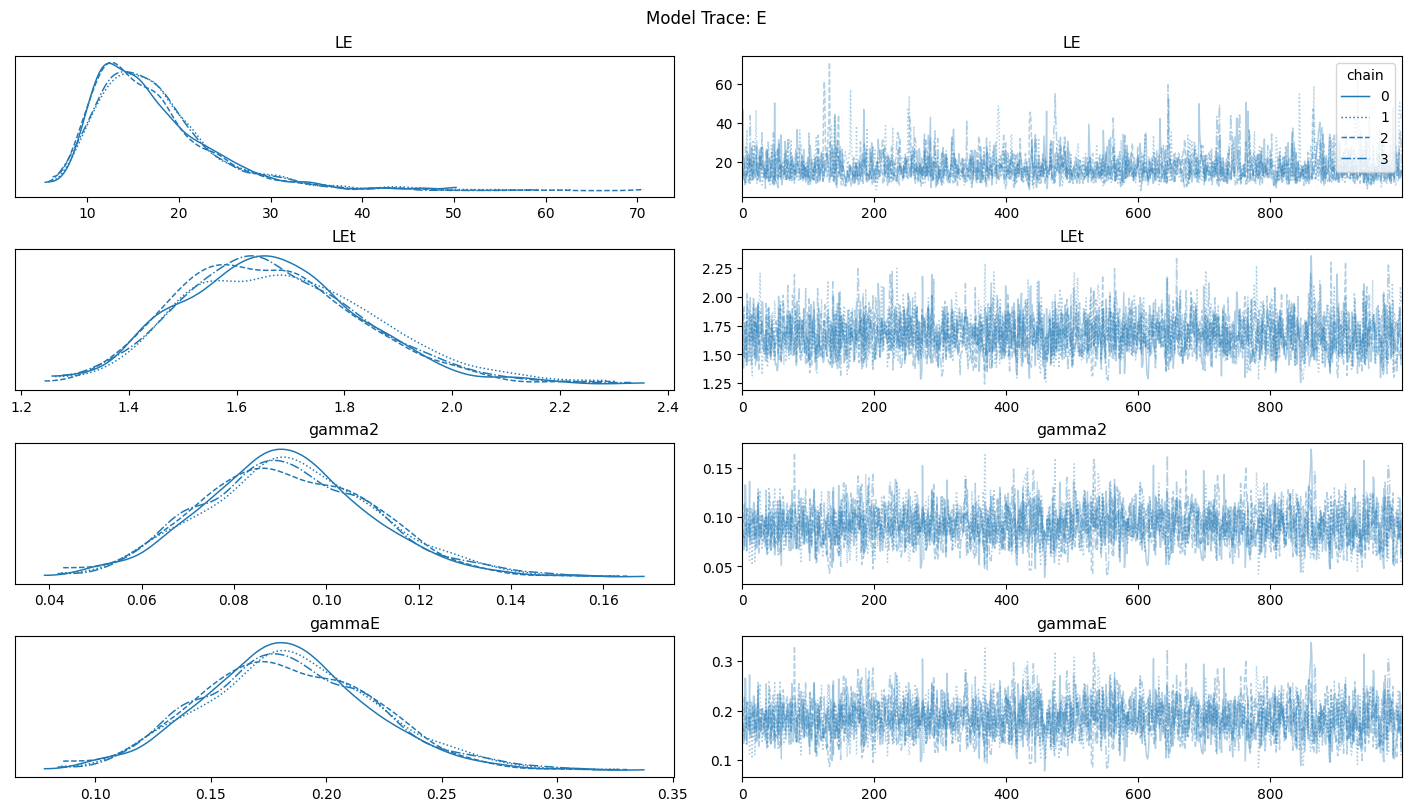

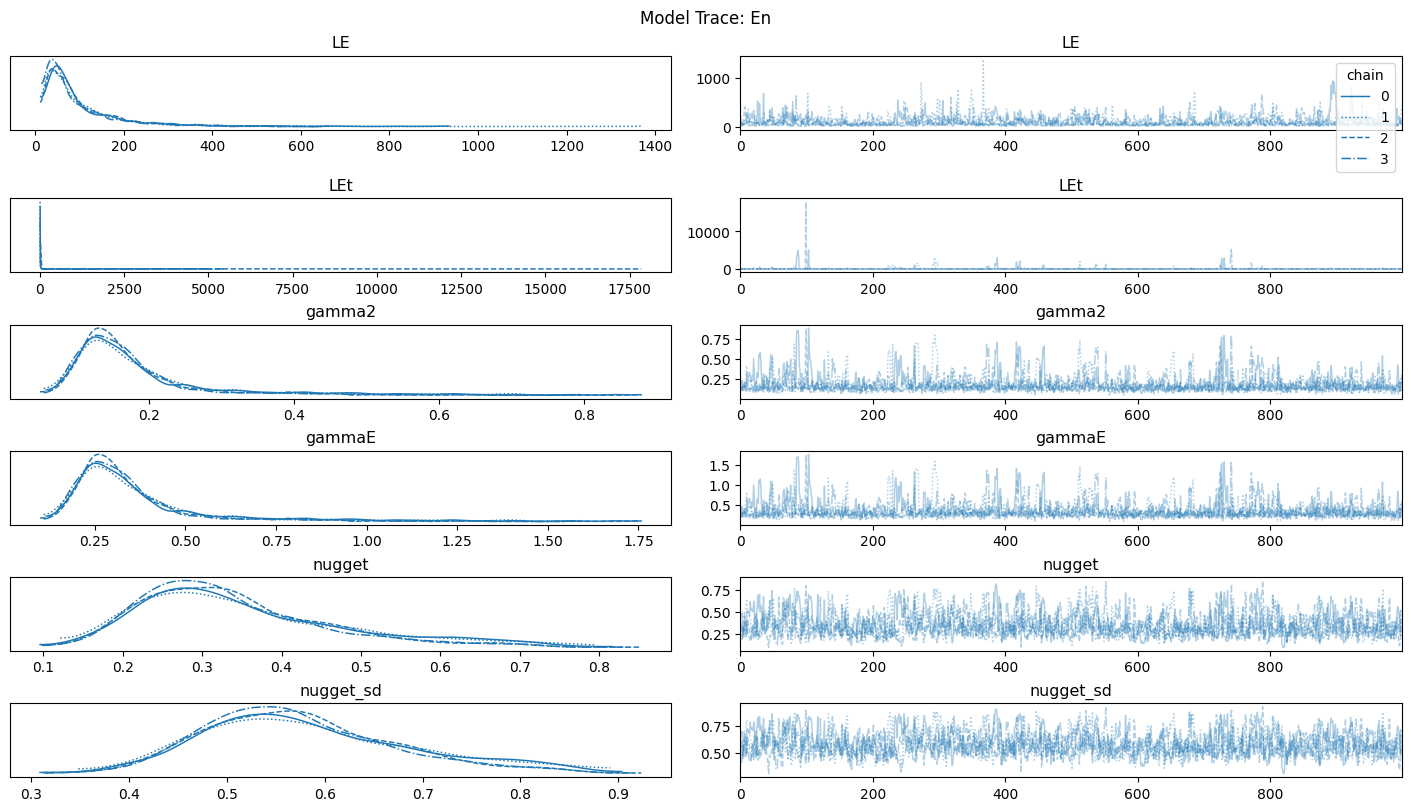

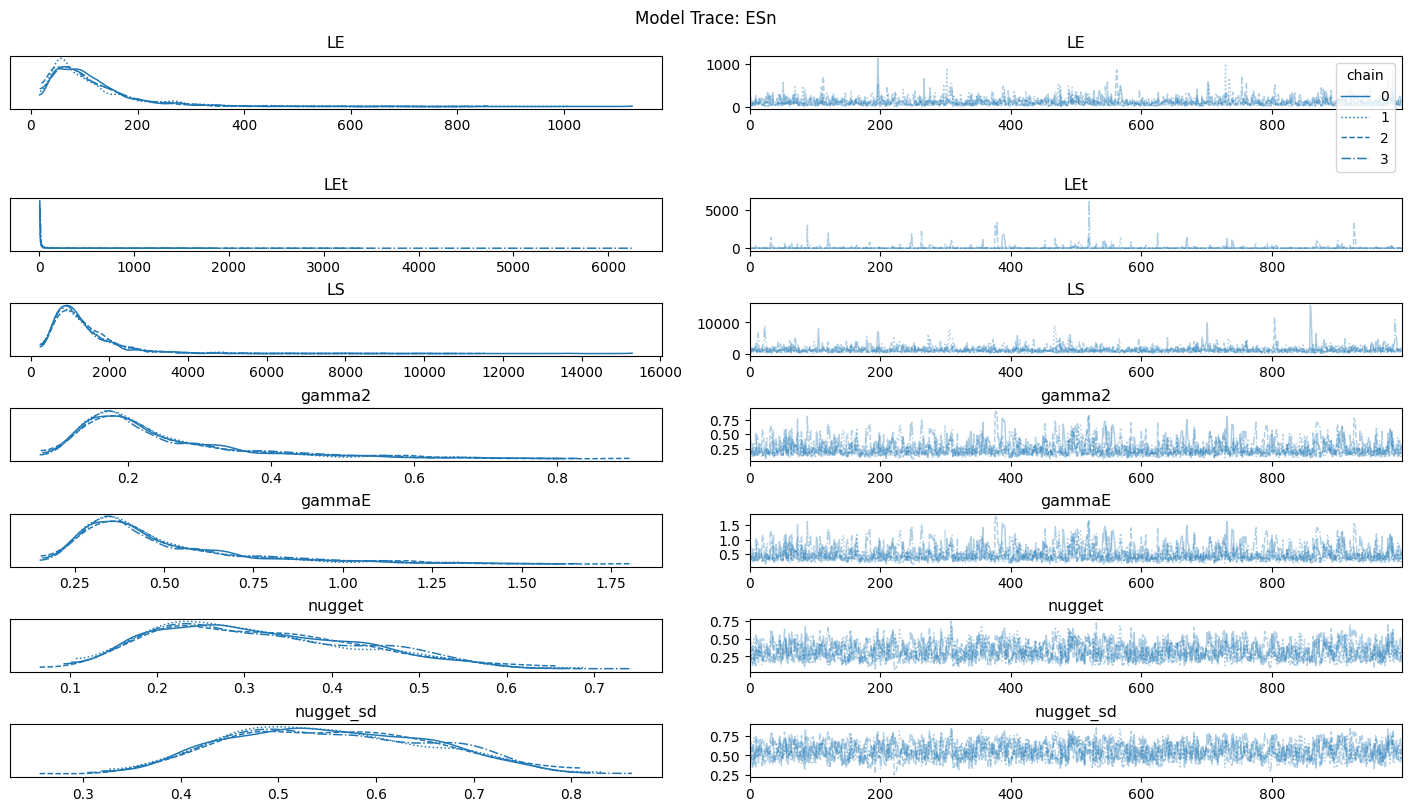

In [18]:
plt.rcParams['figure.constrained_layout.use'] = True

az.plot_trace(data = predictions[0], kind = "trace",legend = True, figsize=(14,8))
plt.suptitle("Model Trace: E")
plt.show()

az.plot_trace(data = predictions[1], kind = "trace",legend = True, figsize=(14,8))
plt.suptitle("Model Trace: En")
plt.show()

az.plot_trace(data = predictions[2], kind = "trace",legend = True, figsize=(14,8))
plt.suptitle("Model Trace: ESn")
plt.show()

## 3.4 LOO-CV

C:\Users\LEGION\Desktop\Python_V2\venv_pymc\Lib\site-packages\arviz\stats\stats.py:840: UserWarning: The point-wise LOO is the same with the sum LOO, please double check the Observed RV in your model to make sure it returns element-wise logp.
  warnings.warn(
C:\Users\LEGION\Desktop\Python_V2\venv_pymc\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
C:\Users\LEGION\Desktop\Python_V2\venv_pymc\Lib\site-packages\arviz\stats\stats.py:840: UserWarning: The point-wise LOO is the same with the sum LOO, please double check the Observed RV in your model to make sure it returns element-wise logp.
  warnings.warn(
C

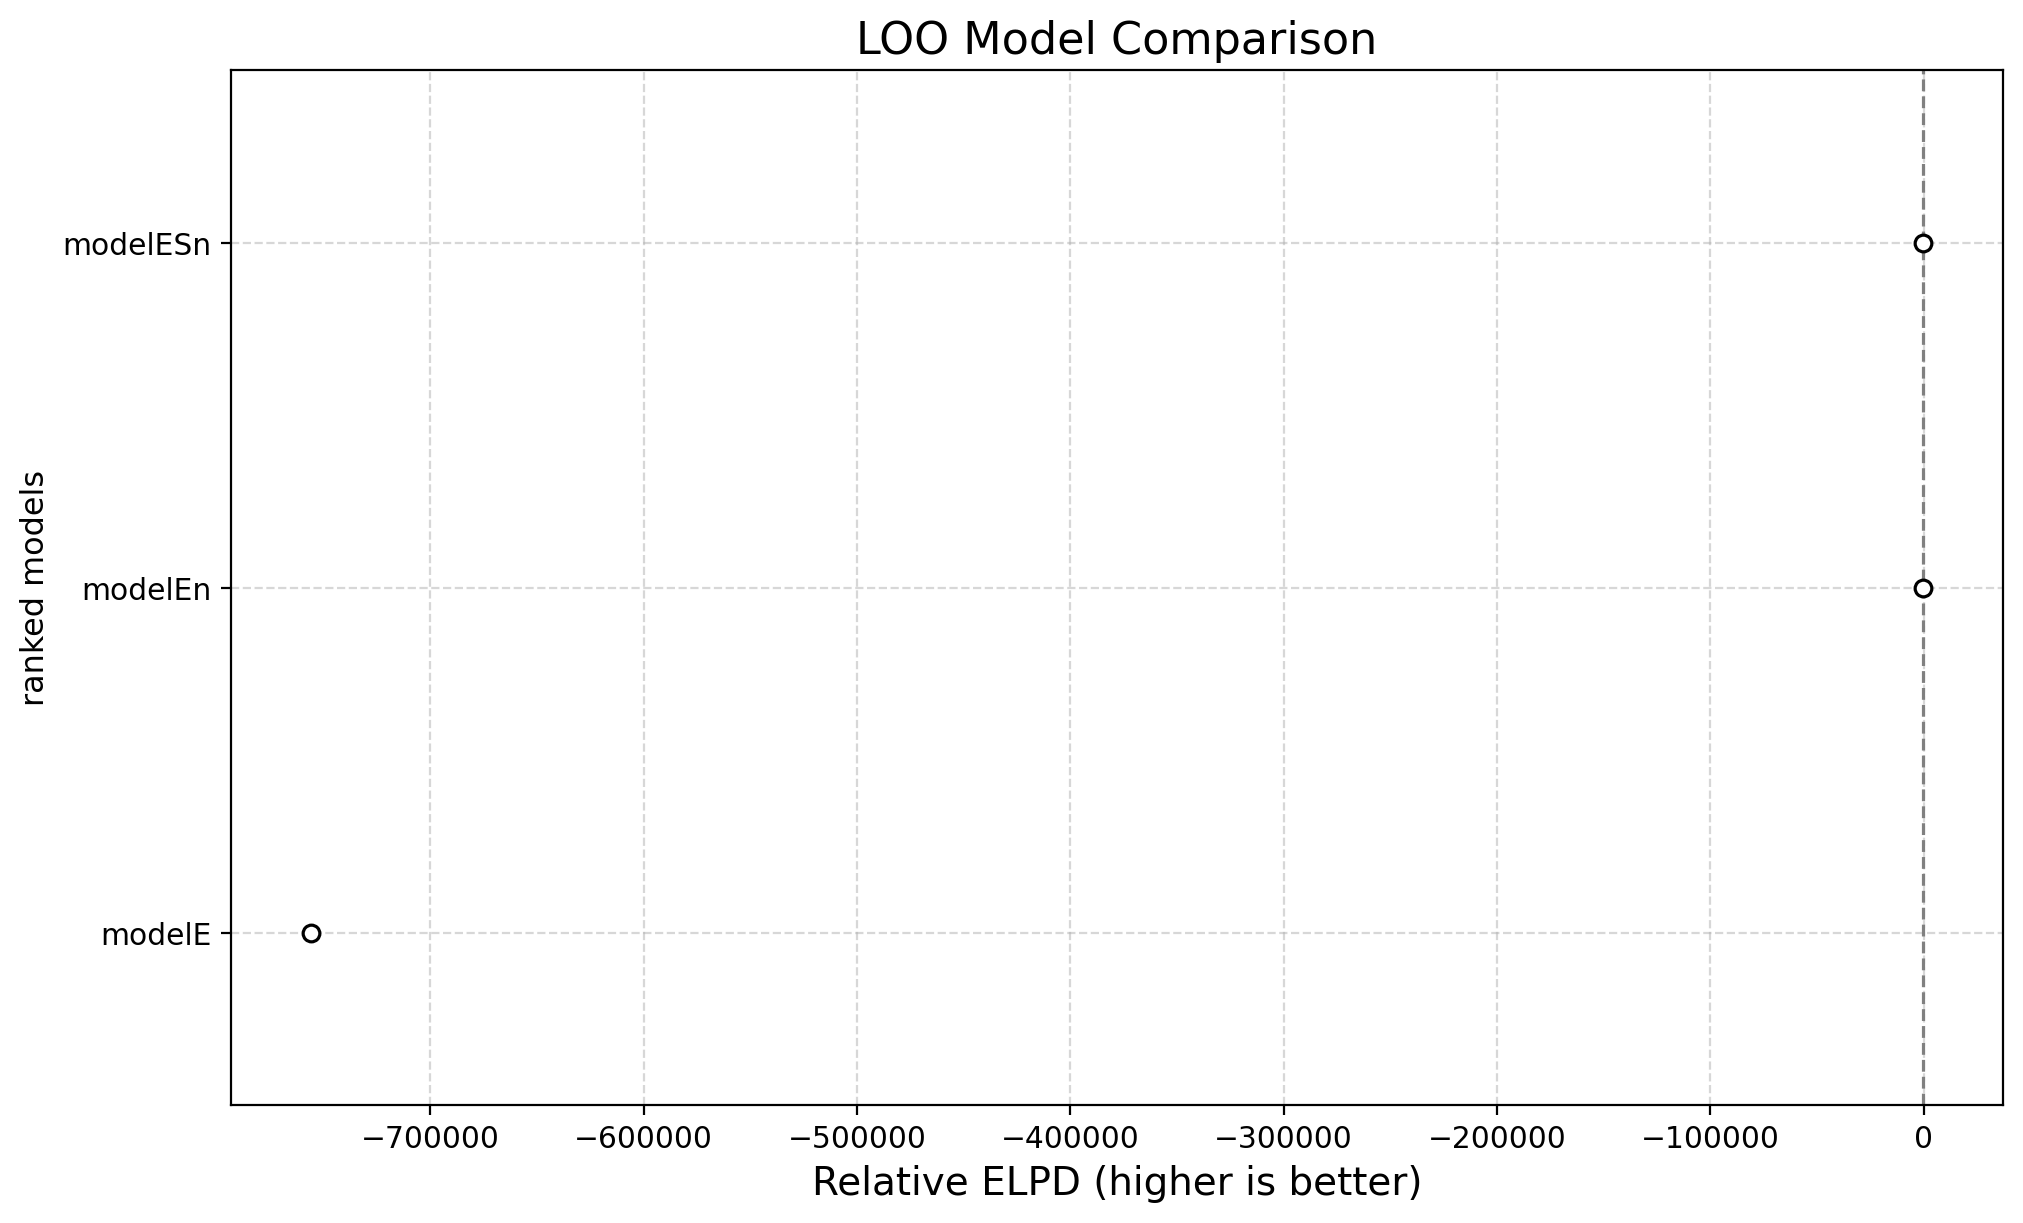

In [20]:
loos = []
for idata in predictions:
    loo = compute_pooled_loo(idata, pointwise=True)
    loos.append(loo)

# Compare all models
compare_df = az.compare({m: l for m, l in zip(model_names, loos)})

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

az.plot_compare(compare_df, ax=ax)

ax.set_title("LOO Model Comparison", fontsize=16)
ax.set_xlabel("Relative ELPD (higher is better)", fontsize=14)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.show()

# 4.0 Empirical Bayesian Kriging

## 4.1 Define Custom Kernels

In [21]:
def kernel_MpE(blocks_nn, blocks_nt, theta):
    """
    MpESn correlation: R = pE * pS, with nugget added to R_nn.
    theta = (lE, gammaE, lS, nugget)
    """
    lE, gammaE = map(float, theta)

    def _safe(D):
        D = np.asarray(D, float)
        return np.where(np.isfinite(D), D, np.inf)

    def pE(D):
        D = _safe(D)
        return np.exp(- (D / lE)**gammaE)

    # nn block
    R_nn = pE(blocks_nn['E'])
    R_nn = 0.5 * (R_nn + R_nn.T)

    # nt block
    R_nt = pE(blocks_nt['E'])

    return R_nn, R_nt

def kernel_MpEn(blocks_nn, blocks_nt, theta):
    """
    MpESn correlation: R = pE * pS, with nugget added to R_nn.
    theta = (lE, gammaE, lS, nugget)
    """
    lE, gammaE, nugget = map(float, theta)

    def _safe(D):
        D = np.asarray(D, float)
        return np.where(np.isfinite(D), D, np.inf)

    def pE(D):
        D = _safe(D)
        return np.exp(- (D / lE)**gammaE)

    # nn block
    R_nn = pE(blocks_nn['E'])
    R_nn = 0.5 * (R_nn + R_nn.T)
    R_nn = R_nn + nugget * np.eye(R_nn.shape[0])

    # nt block
    R_nt = pE(blocks_nt['E'])

    return R_nn, R_nt

def kernel_MpESn(blocks_nn, blocks_nt, theta):
    """
    MpESn correlation: R = pE * pS, with nugget added to R_nn.
    theta = (lE, gammaE, lS, nugget)
    """
    lE, gammaE, lS, nugget = map(float, theta)

    def _safe(D):
        D = np.asarray(D, float)
        return np.where(np.isfinite(D), D, np.inf)

    def pE(D):
        D = _safe(D)
        return np.exp(- (D / lE)**gammaE)

    def pS(D):
        D = _safe(D)
        return np.exp(- D / lS)

    # nn block
    R_nn = pE(blocks_nn['E']) * pS(blocks_nn['S'])
    R_nn = 0.5 * (R_nn + R_nn.T)
    R_nn = R_nn + nugget * np.eye(R_nn.shape[0])

    # nt block
    R_nt = pE(blocks_nt['E']) * pS(blocks_nt['S'])

    return R_nn, R_nt

## 4.2 Get pair-wise distances

In [22]:
# site-site pairwise distances
D_nn_E, D_nt_E = pairwise_distances(coords = k0[['X_km','Y_km']].values, targets = target_values[['X_km','Y_km']].values, distance_type = "cartesian")

# vs30 differences across sites
D_nn_S, D_nt_S = pairwise_distances(coords = k0['vs30'].values.reshape(-1, 1), targets = target_values['vs30'].values.reshape(-1, 1), distance_type = "euclidean")

# create dictionaries
E_nn = {'E': D_nn_E}
E_nt = {'E': D_nt_E}
S_nn = {'S': D_nn_S}
S_nt = {'S': D_nt_S}

blocks_nn, blocks_nt = merge_blocks([E_nn, S_nn], [E_nt, S_nt])

## 4.3 Run EBK

### 4.3.1 Model E

In [23]:
posterior_theta_E = (
        df_param_samples[0]["LE"].values,
        df_param_samples[0]["gammaE"].values
)

posterior_out_E, posterior_predictive_E, _, posterior_quantiles_E = bayes_krig(values=k0['k0_z'].values,
                                                                                                 krig_type="ok",
                                                                                                 blocks_nn=blocks_nn,
                                                                                                 blocks_nt=blocks_nt,
                                                                                                 custom_kernel=kernel_MpE,
                                                                                                 theta=posterior_theta_E,
                                                                                                 sigma2=np.var(k0['k0_z'].values),
                                                                                                 custom_model_family="correlation")

Processing samples:   0%|          | 0/4000 [00:00<?, ?it/s]

### 4.3.2 Model En

In [24]:
posterior_theta_En = (
        df_param_samples[1]["LE"].values,
        df_param_samples[1]["gammaE"].values,
        df_param_samples[1]["nugget"].values
)

posterior_out_En, posterior_predictive_En, _, posterior_quantiles_En = bayes_krig(values=k0['k0_z'].values,
                                                                                                 krig_type="ok",
                                                                                                 blocks_nn=blocks_nn,
                                                                                                 blocks_nt=blocks_nt,
                                                                                                 custom_kernel=kernel_MpEn,
                                                                                                 theta=posterior_theta_En,
                                                                                                 sigma2=np.var(k0['k0_z'].values),
                                                                                                 custom_model_family="correlation")

Processing samples:   0%|          | 0/4000 [00:00<?, ?it/s]

### 4.3.3 Model ESn

In [25]:
posterior_theta_ESn = (
        df_param_samples[2]["LE"].values,
        df_param_samples[2]["gammaE"].values,
        df_param_samples[2]["LS"].values,
        df_param_samples[2]["nugget"].values
)

posterior_out_ESn, posterior_predictive_ESn, _, posterior_quantiles_ESn = bayes_krig(values=k0['k0_z'].values,
                                                                                                 krig_type="ok",
                                                                                                 blocks_nn=blocks_nn,
                                                                                                 blocks_nt=blocks_nt,
                                                                                                 custom_kernel=kernel_MpESn,
                                                                                                 theta=posterior_theta_ESn,
                                                                                                 sigma2=np.var(k0['k0_z'].values),
                                                                                                 custom_model_family="correlation")

Processing samples:   0%|          | 0/4000 [00:00<?, ?it/s]

## 4.4 Plot results

### 4.4.1 Model E

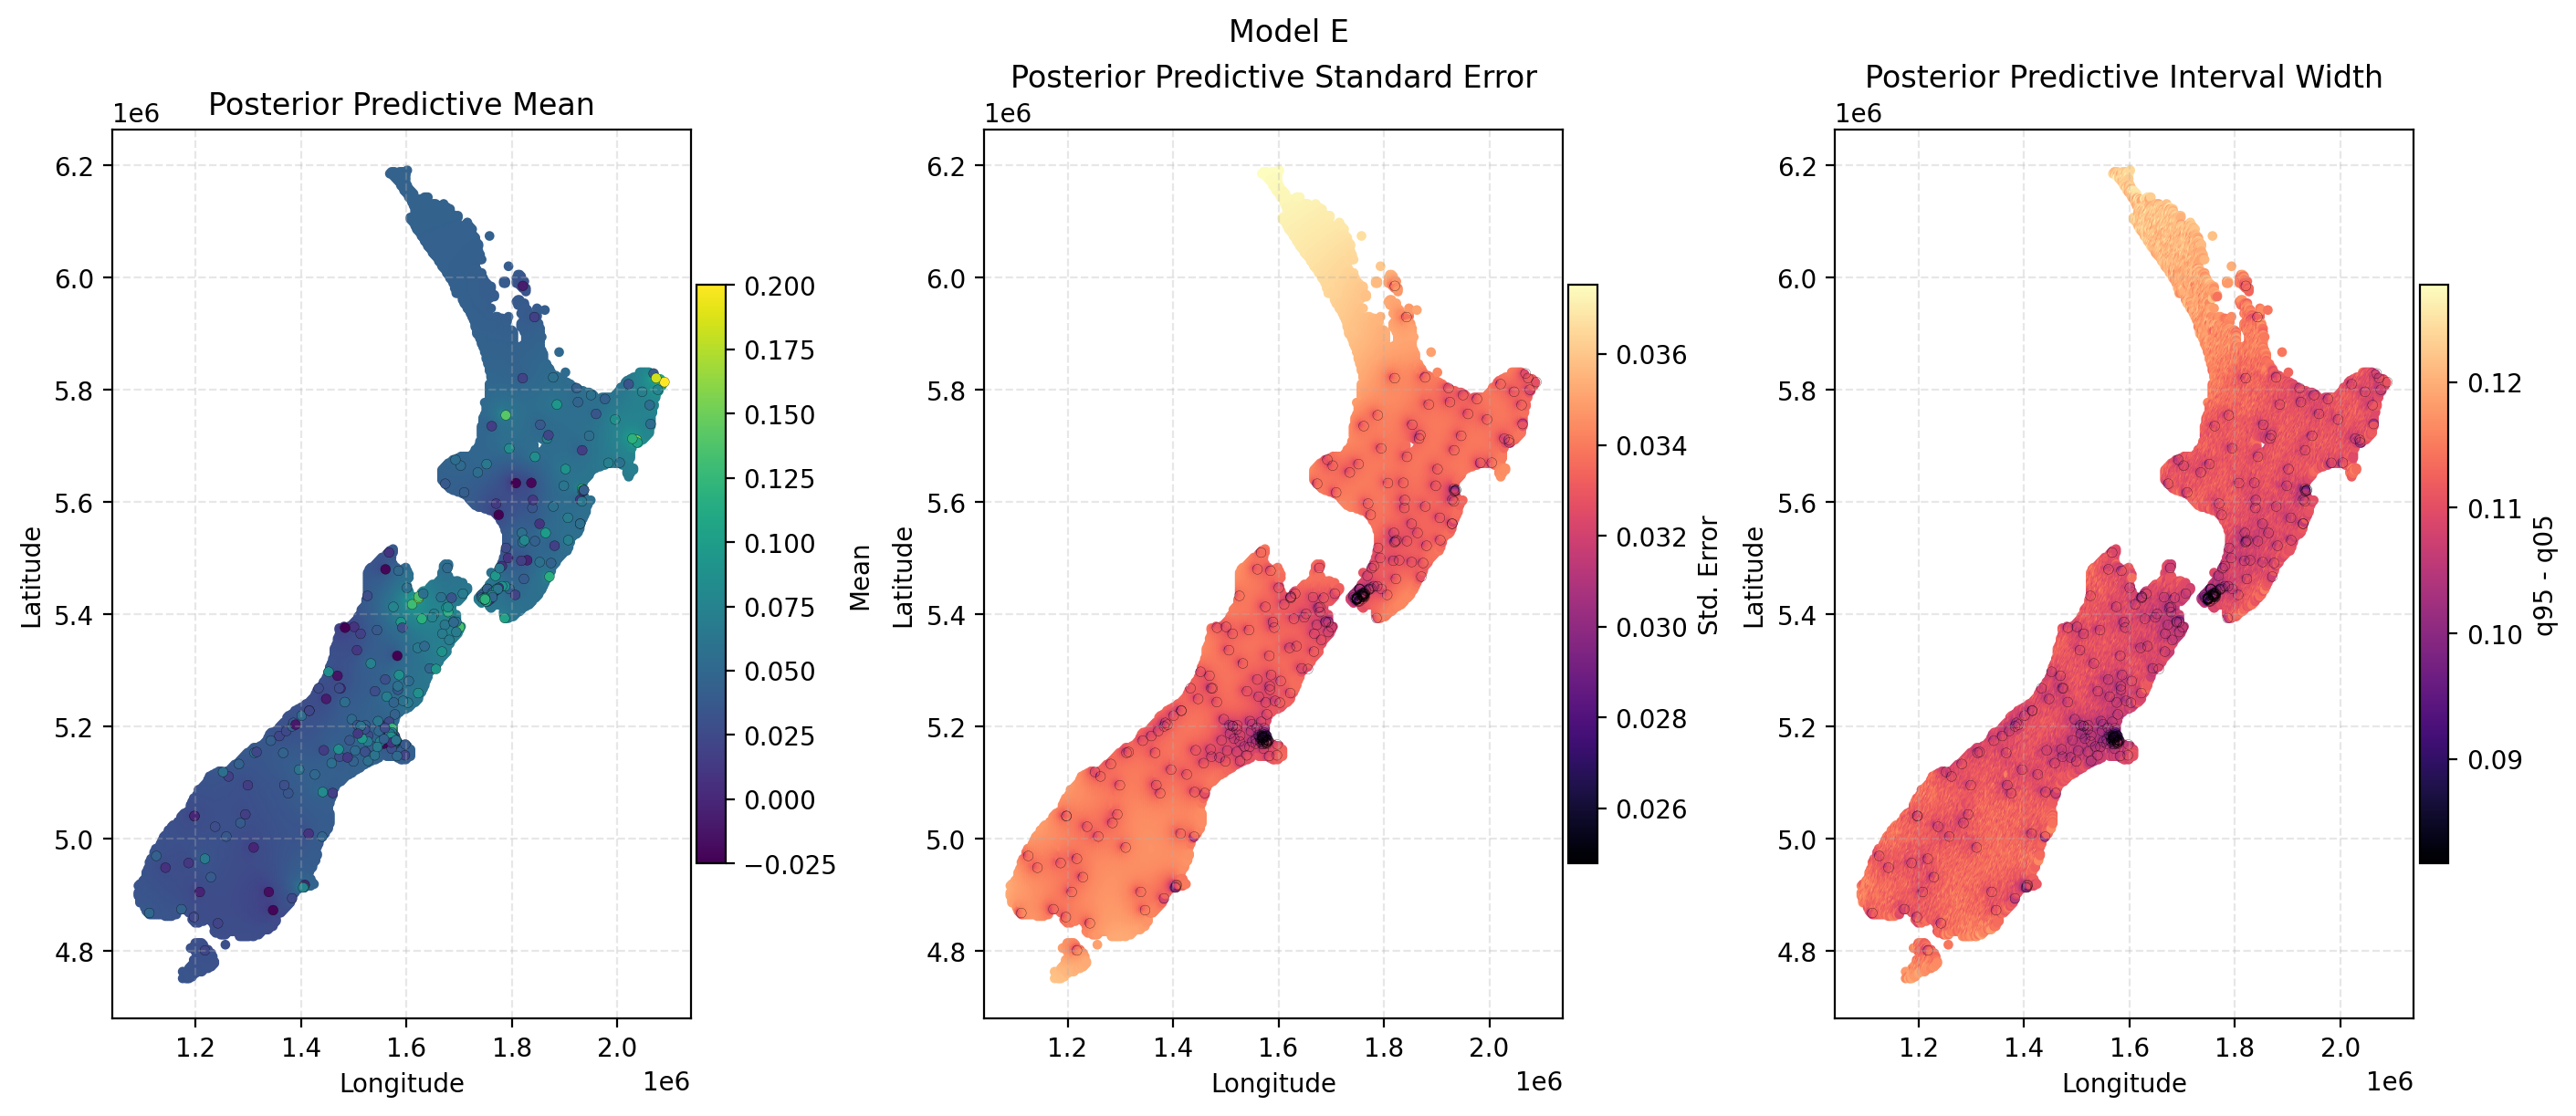

In [38]:
pred_q05_E = posterior_quantiles_E['quantiles'][0.05] * sig + mu
pred_q95_E = posterior_quantiles_E['quantiles'][0.95] * sig + mu
pred_ci_width_E = pred_q95_E - pred_q05_E
prediction_E = posterior_predictive_E['mu'] * sig + mu
std_error_E = posterior_predictive_E['std'] * sig

fig, axes = plt.subplots(1, 3, figsize=(14, 6), dpi=200, constrained_layout=True)

ax = axes[0]
sc0 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=prediction_E, cmap="viridis", s=8, vmin = -0.025, vmax=0.20
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    c=k0['k0_mean'].values, cmap="viridis",
    s=15, edgecolor="k", linewidths=0.1, vmin = -0.025, vmax=0.20
)
cb0 = plt.colorbar(sc0, ax=ax, pad=0.01, fraction=0.05)
cb0.set_label("Mean")
ax.set_title("Posterior Predictive Mean")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)

# Posterior Predictive Standard Error
ax = axes[1]
sc1 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=std_error_E, cmap="magma", s=8
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    facecolors="none", edgecolors="k",
    s=15, linewidths=0.1
)
cb1 = plt.colorbar(sc1, ax=ax, pad=0.01, fraction=0.05)
cb1.set_label("Std. Error")
ax.set_title("Posterior Predictive Standard Error")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)

# Predictive Interval Width (q95 - q05)
ax = axes[2]
sc5 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=pred_ci_width_E, cmap="magma", s=8
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    facecolors="none", edgecolors="k",
    s=15, linewidths=0.1
)
cb5 = plt.colorbar(sc5, ax=ax, pad=0.01, fraction=0.05)
cb5.set_label("q95 - q05")
ax.set_title("Posterior Predictive Interval Width")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)
plt.suptitle('Model E')
plt.show()

### 4.4.2 Model En

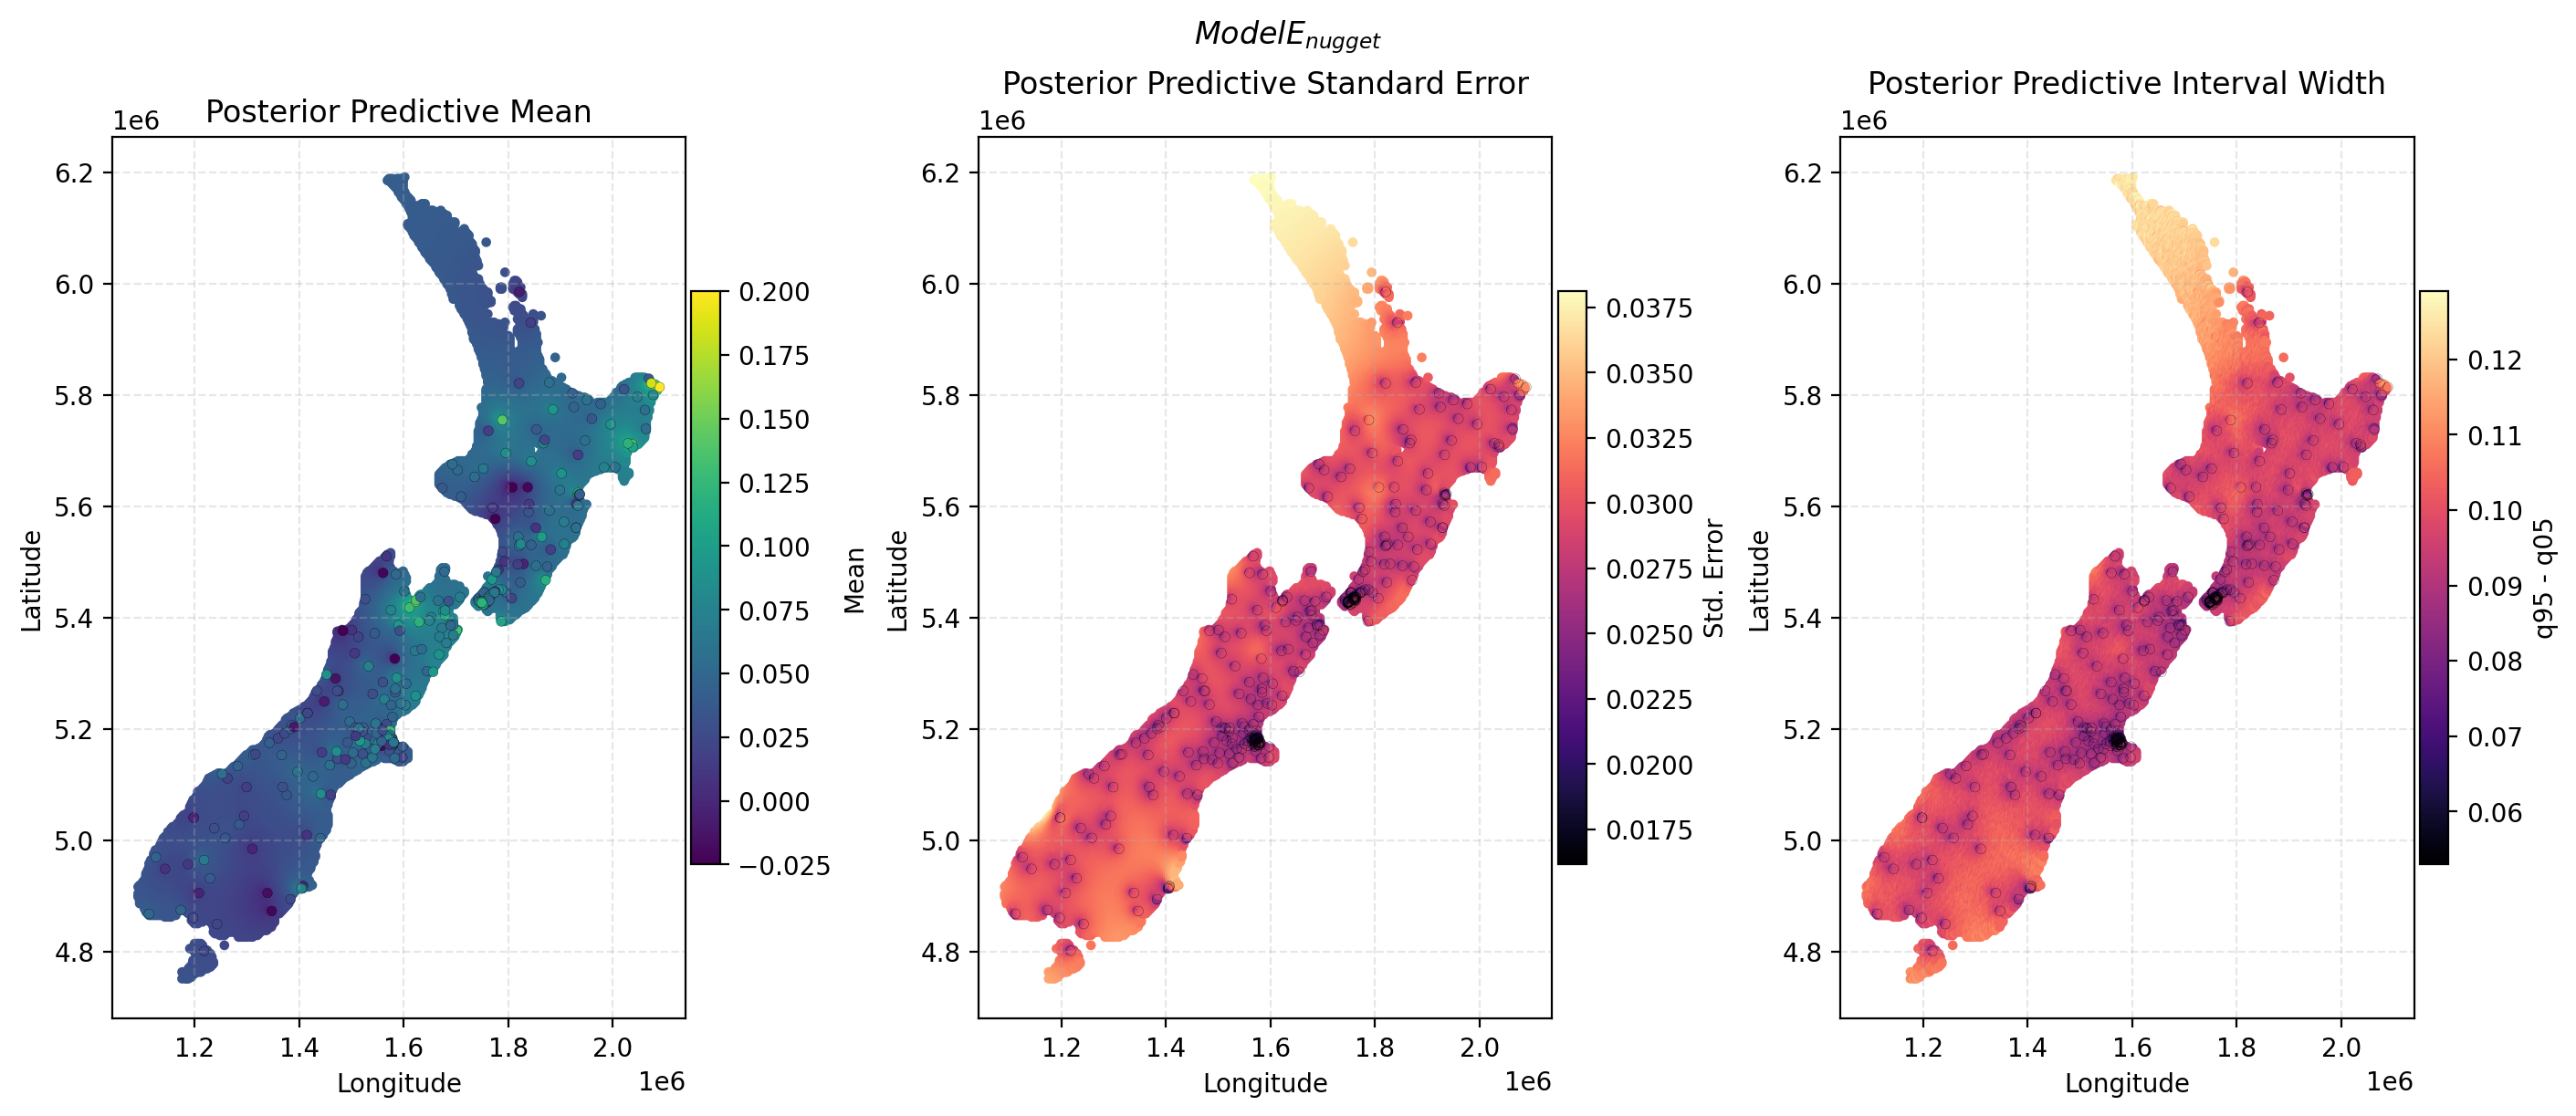

In [39]:
pred_q05_En = posterior_quantiles_En['quantiles'][0.05] * sig + mu
pred_q95_En = posterior_quantiles_En['quantiles'][0.95] * sig + mu
pred_ci_width_En = pred_q95_En - pred_q05_En
prediction_En = posterior_predictive_En['mu'] * sig + mu
std_error_En = posterior_predictive_En['std'] * sig

fig, axes = plt.subplots(1, 3, figsize=(14, 6), dpi=200, constrained_layout=True)

ax = axes[0]
sc0 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=prediction_En, cmap="viridis", s=8, vmin = -0.025, vmax=0.20
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    c=k0['k0_mean'].values, cmap="viridis",
    s=15, edgecolor="k", linewidths=0.1, vmin = -0.025, vmax=0.20
)
cb0 = plt.colorbar(sc0, ax=ax, pad=0.01, fraction=0.05)
cb0.set_label("Mean")
ax.set_title("Posterior Predictive Mean")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)

# Posterior Predictive Standard Error
ax = axes[1]
sc1 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=std_error_En, cmap="magma", s=8
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    facecolors="none", edgecolors="k",
    s=15, linewidths=0.1
)
cb1 = plt.colorbar(sc1, ax=ax, pad=0.01, fraction=0.05)
cb1.set_label("Std. Error")
ax.set_title("Posterior Predictive Standard Error")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)

# Predictive Interval Width (q95 - q05)
ax = axes[2]
sc5 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=pred_ci_width_En, cmap="magma", s=8
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    facecolors="none", edgecolors="k",
    s=15, linewidths=0.1
)
cb5 = plt.colorbar(sc5, ax=ax, pad=0.01, fraction=0.05)
cb5.set_label("q95 - q05")
ax.set_title("Posterior Predictive Interval Width")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)
plt.suptitle(r'$Model E_{nugget}$')
plt.show()

### 4.4.3 Model ESn

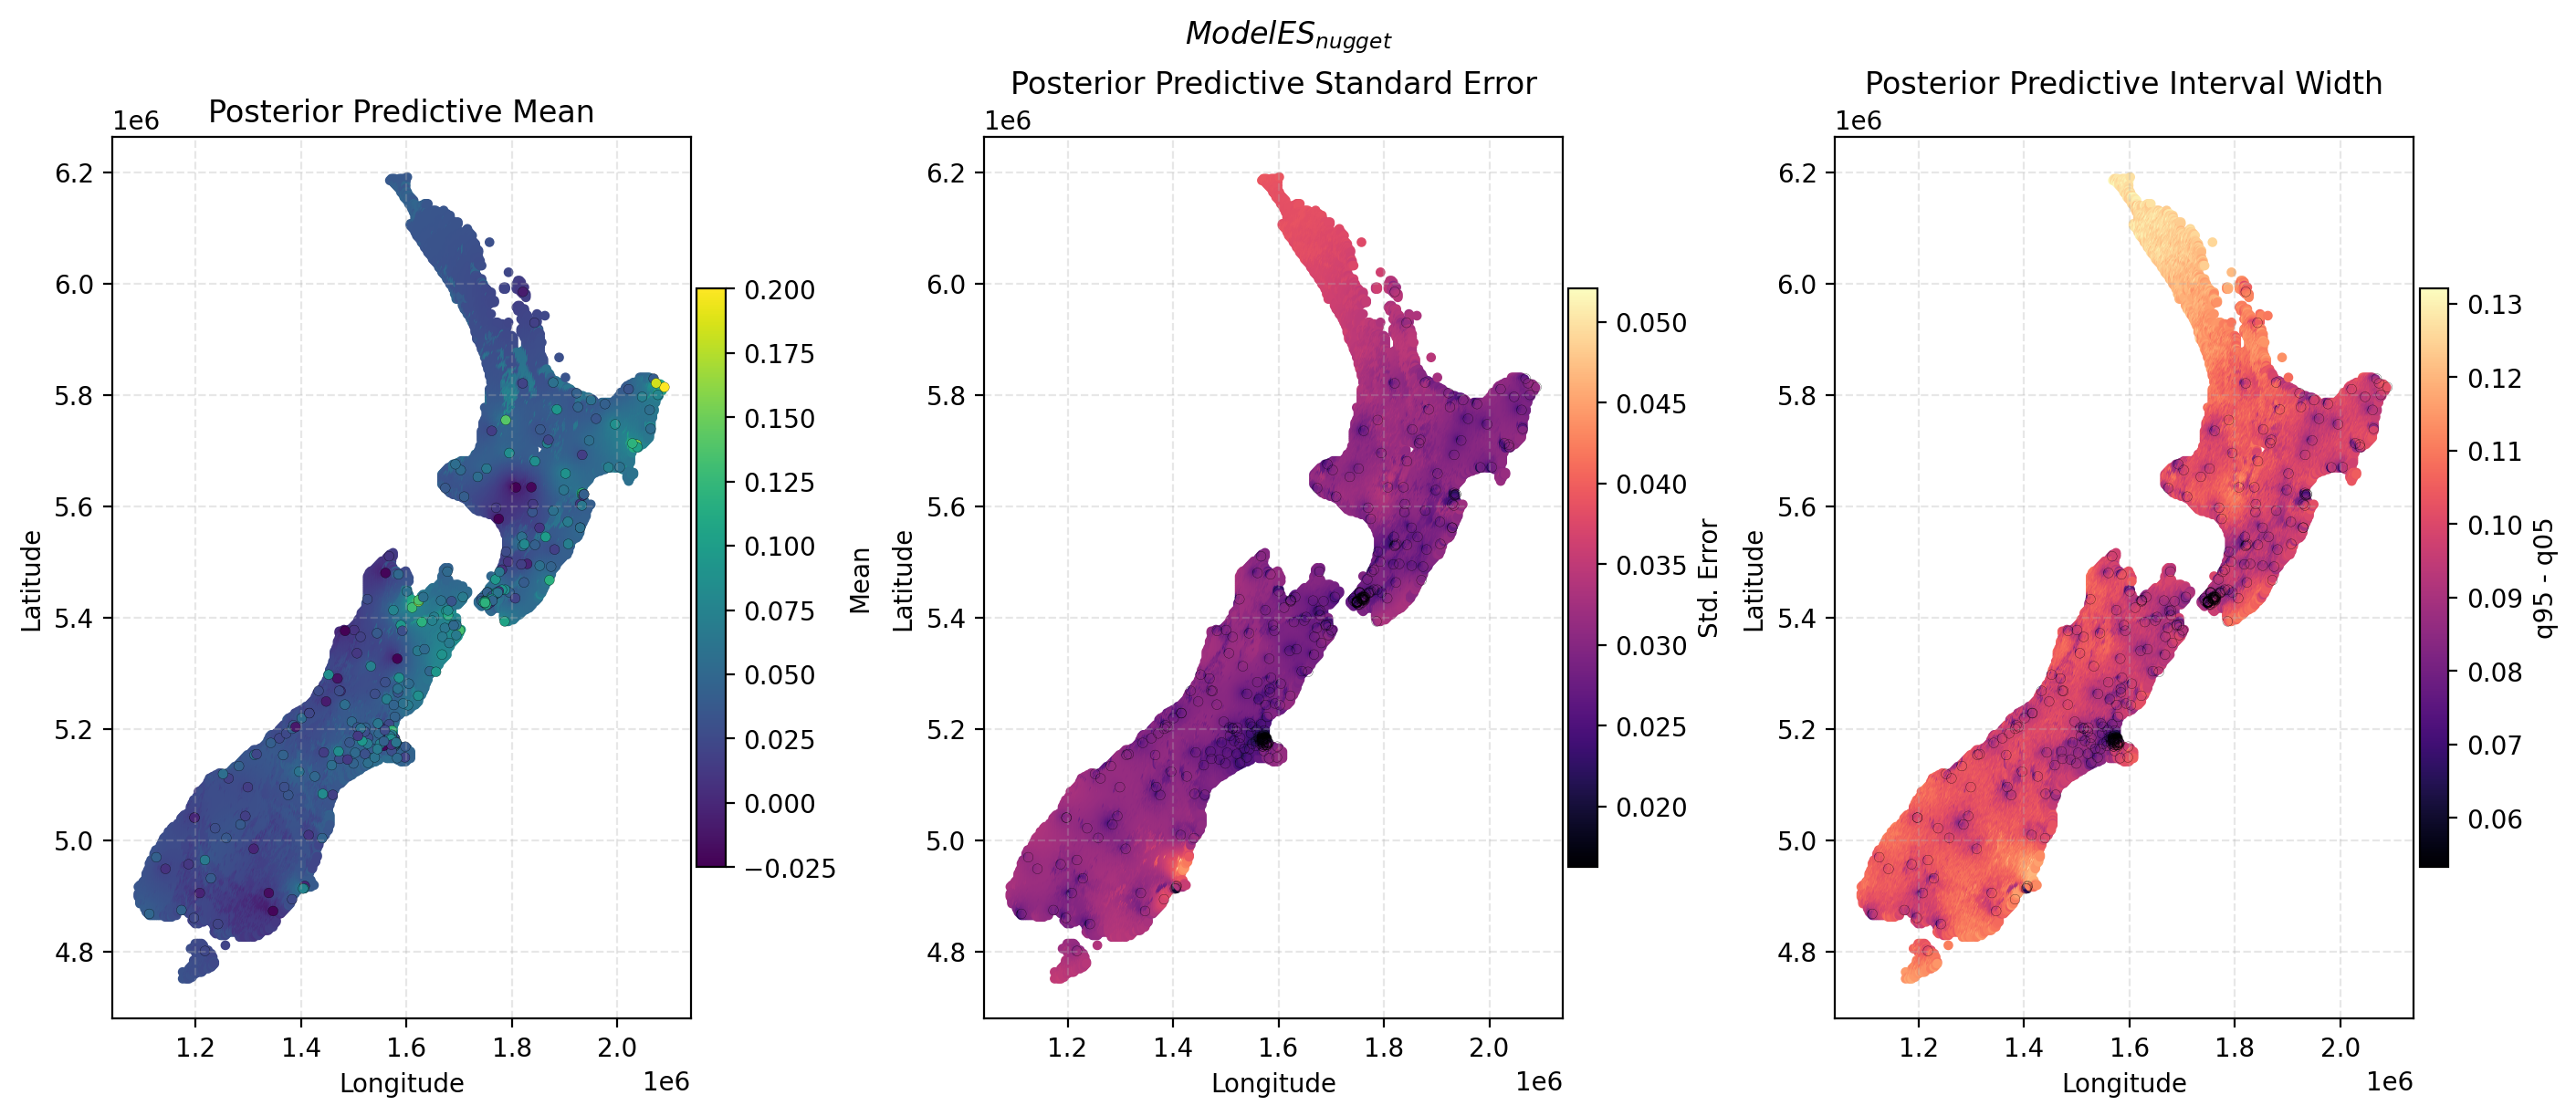

In [40]:
pred_q05_ESn = posterior_quantiles_ESn['quantiles'][0.05] * sig + mu
pred_q95_ESn = posterior_quantiles_ESn['quantiles'][0.95] * sig + mu
pred_ci_width_ESn = pred_q95_ESn - pred_q05_ESn
prediction_ESn = posterior_predictive_ESn['mu'] * sig + mu
std_error_ESn = posterior_predictive_ESn['std'] * sig

fig, axes = plt.subplots(1, 3, figsize=(14, 6), dpi=200, constrained_layout=True)

ax = axes[0]
sc0 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=prediction_ESn, cmap="viridis", s=8, vmin = -0.025, vmax=0.20
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    c=k0['k0_mean'].values, cmap="viridis",
    s=15, edgecolor="k", linewidths=0.1, vmin = -0.025, vmax=0.20
)
cb0 = plt.colorbar(sc0, ax=ax, pad=0.01, fraction=0.05)
cb0.set_label("Mean")
ax.set_title("Posterior Predictive Mean")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)

# Posterior Predictive Standard Error
ax = axes[1]
sc1 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=std_error_ESn, cmap="magma", s=8
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    facecolors="none", edgecolors="k",
    s=15, linewidths=0.1
)
cb1 = plt.colorbar(sc1, ax=ax, pad=0.01, fraction=0.05)
cb1.set_label("Std. Error")
ax.set_title("Posterior Predictive Standard Error")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)

# Predictive Interval Width (q95 - q05)
ax = axes[2]
sc5 = ax.scatter(
    target_values['X_m'], target_values['Y_m'],
    c=pred_ci_width_ESn, cmap="magma", s=8
)
ax.scatter(
    k0['X_m'], k0['Y_m'],
    facecolors="none", edgecolors="k",
    s=15, linewidths=0.1
)
cb5 = plt.colorbar(sc5, ax=ax, pad=0.01, fraction=0.05)
cb5.set_label("q95 - q05")
ax.set_title("Posterior Predictive Interval Width")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.3)
plt.suptitle(r'$Model ES_{nugget}$')
plt.show()